# General Lattice Optimization
**by <span style="color:darkgreen">Rostam Golesorkhtabar</span> & <span style="color:darkgreen">Pasquale Pavone</span> for [<span style="color:darkgoldenrod">exciting *magnesium*</span>](https://www.exciting-code.org/magnesium)**

<font size="2">(Jupyter notebook by <span style="color:darkgreen">Tejus Rohatgi</span>, <span style="color:darkgreen">Mara Voiculescu</span> & <span style="color:darkgreen">Martin Kuban</span>)</font>
<hr style="border:2px solid #DDD"> </hr>

**<span style="color:firebrick">Purpose</span>**:  In this tutorial, you will learn how to <b>optimize</b> a general crystal structure. An explicit example is given for <b>hexagonal</b> structures. Here, you will set up and execute a series of calculations for different volumes (at constant $c/a$ ratio) and for different $c/a$ ratios (at constant volume) for Be in the hexagonal structure. The tools which are used in this tutorial are applicable for <b>any</b> crystal type.

<div class="alert alert-block alert-warning">
    
**Table of Contents**

[0. Before Starting](#0)
    
* [Extra requirement: Tool for space-group determination](#0-1)
    
[1. Basics of lattice optimization](#1)

[2. Preparation of the input file](#2)
    
[3. Lattice optimization of hexagonal crystals](#3)
  
* [STEP1: Optimizing the volume](#3-1)
* [STEP2: Optimizing the $c/a$ ratio](#3-2)
* [STEP3: Optimizing again the volume](#3-3)
* [STEP4: Optimizing again the $c/a$ ratio](#3-4)
* [Reaching convergence](#3-5)
* [Note on the accuracy of the calculations](#3-6)
* [Final step: Internal optimization](#3-7)
    
</div>

<a id='0'></a>
<hr style="border:1px solid #DDD"> </hr>

### <span style="color:#15317E">0. Before Starting</span>

**<span style="color:firebrick">Read the following paragraphs before starting with the rest of this tutorial!</span>**

Before running any Jupyter tutorials, please refer to the **`00_before_starting.md`** document on how to correctly set up the environment. This only needs to be done once. After which, the **venv** can be (re)activated from **`exciting`**'s root directory:

<div style="background-color: rgb(224, 224, 224);">

```bash
source $EXCITINGROOT/tools/excitingjupyter/venv/excitingvenv/bin/activate
```

</div>

Here is a list of the scripts which are relevant for this tutorial with a short description.

* <code><b>optimize.setup.py</b></code>: Python script for generating structures at different volume/strains. 
* <code><b>optimize.analyze.py</b></code>: Python script for fitting the energy-vs-volume and energy-vs-strain curves.
* <code><b>optimize.submit.py</b></code>: Python script for running a series of **`exciting`** calculations.
* <code><b>lattice.parameters.py</b></code>: Python script for extracting the values of the lattice parameters out of any **`exciting`** input file.
* <code><b>exciting2sgroup.py</b></code>: Python script for converting an **`exciting`** input file to an input file for the program <b>sgroup</b>.

<a id='0-1'></a>
<hr style="border:1px solid #DDD"> </hr>

<span style="color:#15317E;font-weight:bold">Extra requirement: Tool for space-group determination</span>

The scripts in this tutorial use the <b>sgroup</b> tool. If you have not done before, this tool should be downloaded and installed.

<hr style="border:1px solid #DDD"> </hr>

<details>
<summary><strong><span style="color:firebrick">$\Rightarrow$ How to check if 'sgroup' is already installed</span></strong> 
    
</summary>    

In order to check if <span style="color:green;font-weight:bold">sgroup</span> is already installed in the computer you are working, write on the command line:

```bash
$ sgroup
```
    
Two possible messages may appear now on the screen.

* First case: <span style="color:green;font-weight:bold">sgroup</span> <span style="color:mediumblue;font-weight:bold">is already installed</span>:

```bash
No input file specified.
```

* Second case: <span style="color:green;font-weight:bold">sgroup</span> <span style="color:firebrick;font-weight:bold">must be installed</span>:

```bash
bash: sgroup: command not found
```
</details>    

<hr style="border:1px solid #DDD"> </hr>

<details>
<summary><strong><span style="color:firebrick">$\Rightarrow$ How to install 'sgroup'</span></strong> 
    
</summary>    

The code <span style="color:green;font-weight:bold">sgroup</span> is a utility which allows to determine the space group and symmetry operations of a crystal structure.

* Tool name: <span style="color:green;font-weight:bold">sgroup</span>
* Authors: <span style="color:green;font-weight:bold">B.Z. Yanchitsky</span>, <span style="color:green;font-weight:bold">A.N. Timoshevskii</span>
* [<span style="color:firebrick;font-weight:bold">Download sgroup here</span>](https://www.exciting-code.org/uploads/exciting/adon_v1_0.tar.gz)

    After the download, you will get the <b>adon_v1_0.tar.gz</b> file, go to the directory where you saved this file and execute the following commands.

```bash
$ tar xfvp adon_v1_0.tar.gz
$ cd SpaceGroups
$ make
$ cp sgroup $EXCITINGROOT/tools/excitingscripts
```

Now, you have everything you need for starting and performing general lattice optimization.
</details>    

<a id='1'></a>
<hr style="border:1px solid #DDD"> </hr>

### <span style="color:#15317E">1.  Basics of lattice optimization</span>

The lattice of a general crystal structure is determined by giving six lattice parameters, $a$, $b$, $c$, $\alpha$, $\beta$, and $\gamma$. The first 3 parameters are connected with the length of the 3 primitive vectors of the crystal; the last 3 are the angles between the primitive vectors. The definition of the lattice parameters can be seen in the following figure taken from the [<span style="color:firebrick;font-weight:bold">wikipedia page on lattice constants</span>](https://en.wikipedia.org/wiki/Lattice_constant).


<figure>
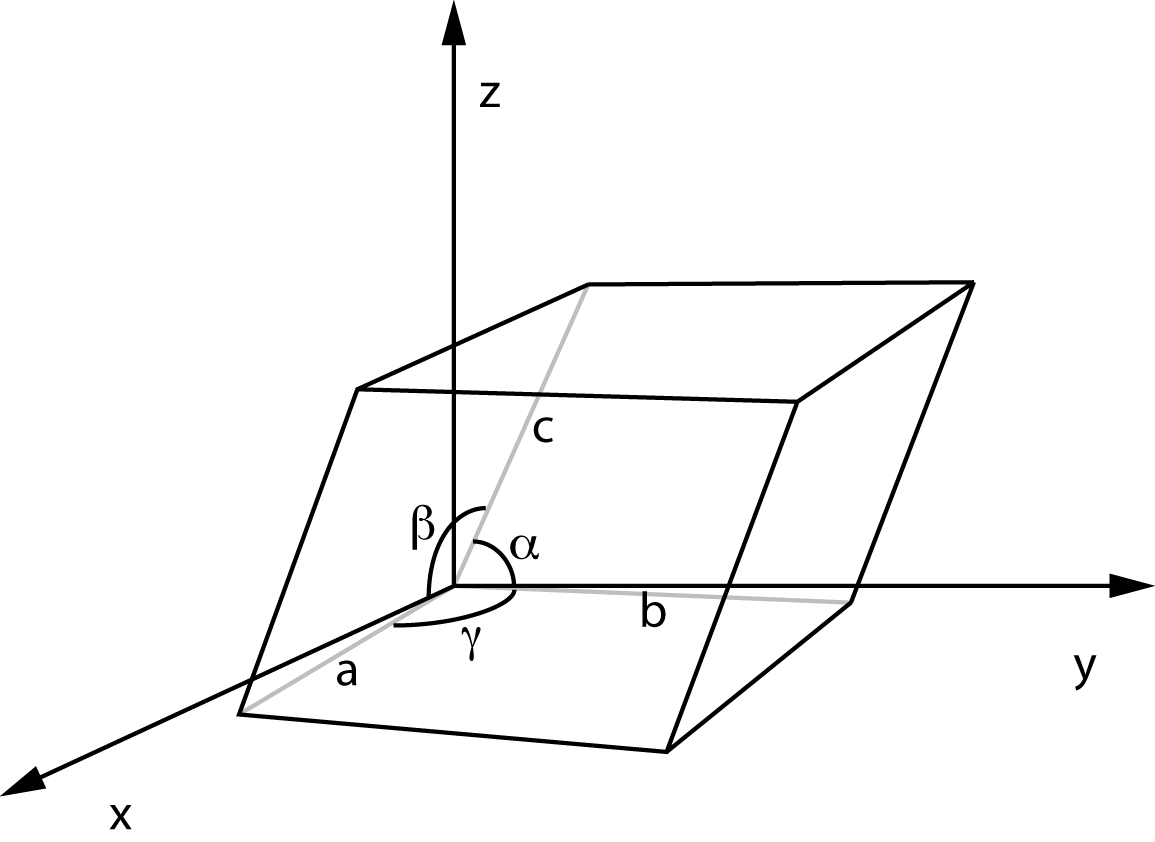
</figure>

In order to perform the optimization of the energy of a crystal with respect to all lattice parameters, we can use an iterative cyclic procedure where in turns one parameter is varied and the remaining 5 are kept fixed. The procedure can be repeated until the obtained equilibrium parameters do not vary anymore within a desired accuracy. In particular, the minimization procedure as performed by the script <code><b>excitingscripts.optimize.lattice</b></code> will contain the following cycles.

1. Minimization with respect to the volume $V$ (by applying an isotropic strain).
2. Minimization with respect to the $b/a$ ratio (all other parameters are fixed).
3. Minimization with respect to the $c/a$ ratio (all other parameters are fixed).
4. Minimization with respect to the angle $\alpha$ between the $b$ and $c$ axes (all other parameters are fixed).
5. Minimization with respect to the angle $\beta$ between the $a$ and $c$ axes (all other parameters are fixed).
6. Minimization with respect to the angle $\gamma$ between the $a$ and $b$ axes (all other parameters are fixed).

In the example reported in this tutorial, we consider a crystal with hexagonal crystal structure. In this case there are only two free parameters, the volume $V$ and the $c/a$ ratio. In the next, we show how to perform the lattice optimization with respect to these two parameters.

<a id='2'></a>
<hr style="border:1px solid #DDD"> </hr>

### <span style="color:#15317E">2. Preparation of the input file</span>

The first step is to create a directory for each system that you want to investigate. In this tutorial, we consider as an example the calculation of energy-vs-volume and energy-vs-strain curves for Be in the hexagonal structure. Therefore, we create a directory <b>run_Be_OPT</b>.

In [ ]:
%%bash -l 
mkdir -p run_Be_OPT

Inside this directory, we create or copy an input file for hexagonal Be with the name <b>Be_opt.xml</b>. In this tutorial is not necessary to rename the input file as <b>input.xml</b>, because this file is the input of a specific script used in this tutorial and not of **`exciting`** itself. Please, notice that the input file for a <span style="color:firebrick;font-weight:bold">direct</span> **`exciting`** calculation must be always called <b>input.xml</b>.

This file should look like the following

<span class="BE_OPT_INPUT"></span>
```xml
<input>
 
   <title>Be: Lattice optimization</title>
 
   <structure speciespath="$EXCITINGROOT/species">
 
      <crystal scale="4.300">
         <basevect>  1.00000000  0.00000000  0.00000000 </basevect>
         <basevect> -0.50000000  0.86602540  0.00000000 </basevect>
         <basevect>  0.00000000  0.00000000  1.50000000 </basevect>
      </crystal>
 
      <species speciesfile="Be.xml" rmt="1.95">
         <atom coord="0.66666667 0.33333333 0.75000000"/>
         <atom coord="0.33333333 0.66666667 0.25000000"/>
      </species>
 
   </structure>
 
   <groundstate 
      ngridk="6 6 4"
      xctype="GGA_PBE_SOL">
   </groundstate>
 
   <relax/>
 
</input>
```

In [ ]:
from excitingjupyter.utilities import get_input_xml_from_notebook

input_str = get_input_xml_from_notebook("general_lattice_optimization", "BE_OPT_INPUT")

# Write out the input as an XML file:
with open('./run_Be_OPT/Be_opt.xml', "w") as fid:
    fid.write(input_str)

<b>Be sure</b> to set the correct path for the **`exciting`** root directory (indicated in this example by <code><span style="color:mediumblue">$EXCITINGROOT</span></code>) to the one pointing to the place where the **`exciting`** directory is placed. In order to do this, use the command


In [ ]:
%%bash -l
cd run_Be_OPT
python3 -m excitingscripts.setup.excitingroot -i Be_opt.xml -o Be_opt.xml
cd ..

The values of the initial lattice parameters, $a$, $b$, $c$, $\alpha$, $\beta$, and $\gamma$, corresponding to the initial input file <b>Be_opt.xml</b> can be extracted using the following command

In [ ]:
%%bash -l
cd run_Be_OPT
python3 -m excitingscripts.lattice.parameters -i Be_opt.xml
cd ../

As an output on the screen you should get

```
     Bravais lattice: Hexagonal
     a          b          c          alpha      beta       gamma
     4.30000    4.30000    6.45000   90.00000   90.00000  120.00000
```

<div style="border: 2px solid black; padding: 10px; margin: 10px;">
<span style="color:red"><b>Please note:</b></span>

* The values of the parameter <code><span style="color:mediumblue">ngridk</span></code> in the input file have been chosen in order to allow for a fast calculation. Of course, the complete optimization procedure presented in this tutorial should be repeated for more accurate values of <code><span style="color:mediumblue">ngridk</span></code> and the other computational parameters up to the desidered accuracy in the resulting lattice constants.
</div>

<a id='3'></a>
<hr style="border:1px solid #DDD"> </hr>

### <span style="color:#15317E">3. Lattice optimization of hexagonal crystals</span>

In the next, we illustrate the iterative procedure for performing the optimization of the crystal structure of hexagonal Beryllium. The only relevant parameters in this case are the volume of the unit cell and the $c/a$ ratio.

<a id='3-1'></a>
<b>STEP1: Optimizing the volume</b>

At the first step, we optimize the energy with respect to the volume. In order to generate input files for a series of volumes you have to use the script <code><b>excitingscripts.optimize.setup</b></code>.

In [ ]:
%%bash -l
cd run_Be_OPT
python3 -m excitingscripts.optimize.setup -i Be_opt.xml --opt 1 --s-max 0.03 -n 5
cd ../

The entry values must be inlcuded when running the script. In this case, the entries are the following.

1. <span style="color:firebrick;font-weight:bold">Be_opt.xml</span>, the name of the input file you have created.
2. <span style="color:firebrick;font-weight:bold">1</span>, the type of optimization you choose.
3. <span style="color:firebrick;font-weight:bold">0.03</span>, the absolute value of the maximum strain, $\epsilon_{max}$, for which we want to perform the calculation. Notice that in this case the physical strain $\epsilon$ is defined by the relationship $V=V_{initial} \cdot (1+\epsilon)^3$, where $V_{initial}$ is the volume of the unit cell defined in <b>Be_opt.xml</b>.
4. <span style="color:firebrick;font-weight:bold">5</span>, the number of deformed structures equally spaced in strain, which are generated between the maximum negative strain and the maximum positive one.

If you do so, the screen output will be similar to the following:

```
     Number and name of space group: 194 (P 63/m m c) 
     Hexagonal I structure in the Laue classification.

     Parameters to optimize:

     1 ... volume
     2 ... c/a ratio with constant volume

     1 -> Parameter to optimize is volume

     Maximum physical strain is 0.03

     Number of distorted structures is 5
```


Now, you must move to the directory <b>VOL</b> and execute the calculation there. If you list the contents of directory, you should see something like:

```
INFO_VOL
source.xml
vol-Parameters
vol_1
vol_2
vol_3
vol_4
vol_5

```

In [ ]:
%%bash -l
cd run_Be_OPT/VOL
ls
cd ../../

To execute the calculations, you have to run the script <code><b>excitingscripts.optimize.submit</b></code>. If you do so, the screen output will be similar to the following.

In [ ]:
%%bash -l 
cd run_Be_OPT/VOL
python3 -m excitingscripts.optimize.submit 
cd ../../

When calculations finished to run, results can be analyzed. In order to do this, you have to run again the <code><b>optimize.analyze.py</b></code> python script in the current directory.

In [ ]:
%%bash -l 
cd run_Be_OPT/VOL
python3 -m excitingscripts.optimize.analyze --eos b
cd ../../

At this point, you need to specify whether you desire to use a [<span style="color:firebrick;font-weight:bold">Murnaghan</span>](http://en.wikipedia.org/wiki/Murnaghan_equation_of_state) (<span style="color:red;font-weight:bold">M</span>) or [<span style="color:firebrick;font-weight:bold">Birch-Murnaghan</span>](http://en.wikipedia.org/wiki/Birch%E2%80%93Murnaghan_equation_of_state) (<span style="color:red;font-weight:bold">B</span>) equation of state for extracting equilibrium parameters such as the equilibrium volume and bulk modulus.

Therefore, if you type <b>B</b> or <b>b</b> as an entry on the command line, you will get as a result

```

  =====================================================================
 Fit accuracy:
     Log(Final residue in [Ha]): -6.03

 Final parameters:
     E_min =  -29.3609602 [Ha]
     V_min =  106.587 [Bohr^3]
     B_0   =  121.952 [GPa]
     B'    =  3.553

 Optimized lattice parameter saved into the file: "BM-optimized.xml"
 =====================================================================


```

Here, if you list the contents of directory, you will see the script has generated some new files

In [ ]:
%%bash -l
cd run_Be_OPT/VOL
ls
cd ../../

You should see something like:
```
BM_eos.out
BM_eos.png
INFO_VOL
energy-vs-volume
source.xml
vol-Parameters
vol-optimized.xml
vol_1
vol_2
vol_3
vol_4
vol_5

```
The <b>BM_eos.out</b> file, for instance, contains all final fit parameters and pressures which are calculated from equation of state fitting procedure. Also, the script generates a plot, a PNG (<b>BM_eos.png</b>) file, which looks like the following.

<figure>
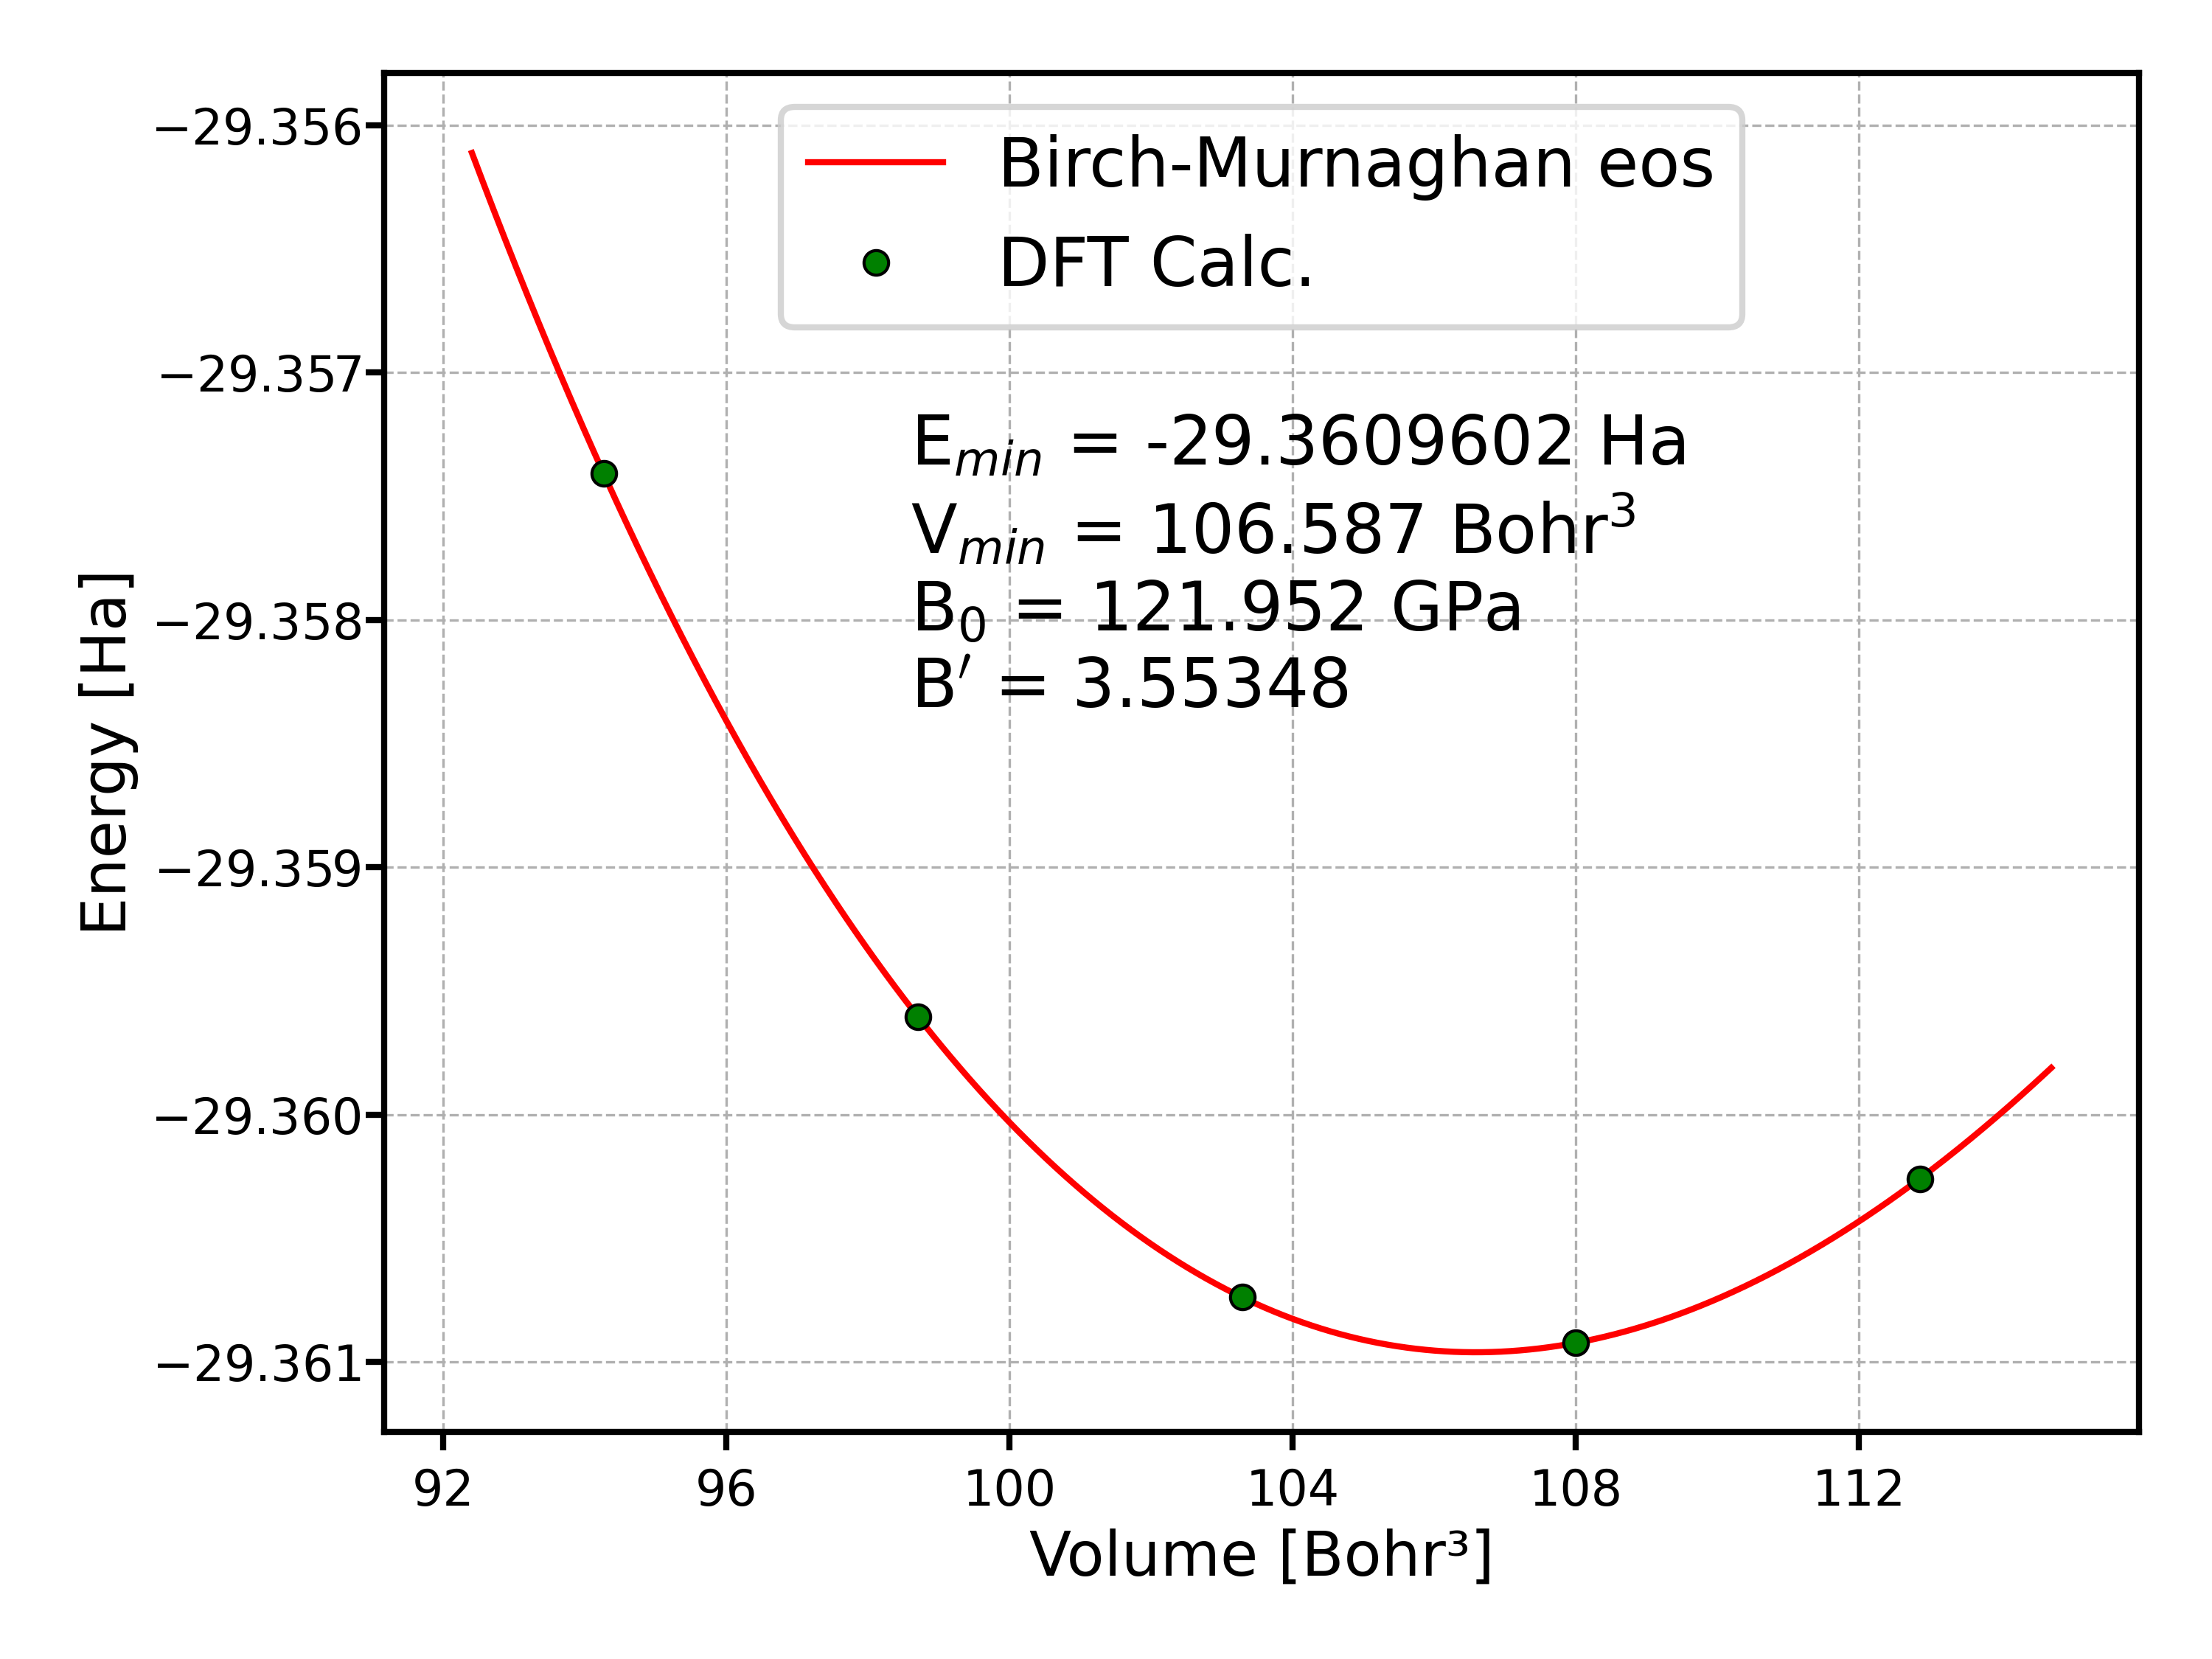
</figure>

On this plot, you can also find the optimized values of the parameters appearing in the equation of state (minimum energy, equilibrium volume, bulk modulus, and bulk modulus pressure derivative).

<div style="border: 2px solid black; padding: 10px; margin: 10px;">
<span style="color:firebrick"><b>Please note:</b></span>

1. The bulk modulus and bulk modulus pressure derivative which are derived here have to be interpreted <span style="color:green;font-weight:bold">only</span> as fitting parameters. This is due to the fact that in this tutorial we are changing the volume, however, we are keeping all other lattice parameter constant. In order to obtain the real physical bulk modulus and bulk modulus pressure derivative, one has to fully optimize at each given volume with respect to <span style="color:firebrick;font-weight:bold">all other lattice and internal parameters</span> (e.g., in the case of hexagonal beryllium, with respect to the <i>c/a</i> ratio, too).
2. The visual analysis of the plots is <span style="color:green;font-weight:bold">very important</span>. <span style="color:firebrick;font-weight:bold">The user should always check them at each step</span>. In particular, if the minimum lies <span style="color:firebrick;font-weight:bold">outside</span> the displayed region, the calculation should be restarted with more appropriate values of the initial parameters (e.g., volume or <i>c/a</i> ratio). The optimal situation is when the minimum of the energy curves is located in the middle of the investigated region.
3. If the difference in energy between the calculated points and the fit is larger than the final required accuracy in the energy, the calculation should be restarted with more appropriate computational parameters. In particular, one should consider the number of <b>k</b> points (<code><span style="color:mediumblue">ngridk</span></code>), the value of <code><span style="color:mediumblue">rgkmax</span></code>, and the accuracy in the calculated total energy (<code><span style="color:mediumblue">epsengy</span></code>).
</div>

A file corresponding to an <code><b>exciting</b></code> input file for the optimized geometry is created with the name <b>BM-optimized.xml</b>. The values lattice parameters $a$, $b$, $c$, $\alpha$, $\beta$, and $\gamma$ at this step can be visualized using the command:

In [ ]:
%%bash -l
cd run_Be_OPT/VOL
python3 -m excitingscripts.lattice.parameters -i BM-optimized.xml
cd ../../

As an output on the screen you should get

```
     Bravais lattice: Hexagonal
     a          b          c          alpha      beta       gamma
     4.34538    4.34538    6.51806   90.00000   90.00000  120.00000
```

Due to the fact that in this step the volume only has been optimized, the relative variation with respect to the initial values of the three lattice parameters <i>a</i>, <i>b</i>, and <i>c</i> is the same. If you are interested to check how accurate the calculated equilibrium parameters at this step are, you can find more information [<span style="color:firebrick;font-weight:bold">here</span>](http://en.wikipedia.org/wiki/Beryllium).

At this point, you have performed the first optimization step by varying only the volume. In order to be prepared for the next step, you should move now to the parent directory and rename the <b>VOL</b> directory to <b>1-VOL</b> (first step, optimizing only the volume). Then, you should copy the <b>BM-optimized.xml</b> file to the current directory with the new name <b>1-optimized.xml</b>. This file will be used as the input file in the next step.

In [ ]:
%%bash -l
cd run_Be_OPT
mv VOL 1-VOL
cp 1-VOL/BM-optimized.xml 1-optimized.xml
cd ../

<a id='3-2'></a>
<hr style="border:1px solid #DDD"> </hr> 

<b>STEP2: Optimizing the</b> $c/a$ <b>ratio</b>

In order to perform the next optimization step, you have to run again <code><b>optimize.setup.py</b></code> in the <b>Be_OPT</b> directory, typing entries like in the following.

In [ ]:
%%bash -l
cd run_Be_OPT
python3 -m excitingscripts.optimize.setup -i 1-optimized.xml --opt 2 --s-max 0.03 -n 5
cd ../

Notice that in this case the physical strain $\epsilon$ is defined by the relationship $(c/a)=(c/a)_{initial}\cdot (1+\epsilon)$, where $(c/a)_{initial}$ corresponds to the unit cell defined in <b>1-optimized.xml</b>. Now, move to the <b>COA</b> directory and run <code><b>optimize.submit.py</b></code>.

In [ ]:
%%bash -l
cd run_Be_OPT/COA
python3 -m excitingscripts.optimize.submit 
cd ../../

When calculations are finished, run again <code><b>optimize.analyze.py</b></code>.

In [ ]:
%%bash -l 
cd run_Be_OPT/COA
python3 -m excitingscripts.optimize.analyze
cd ../../

In this case, the optimization is performed using a fourth-order polynomial fit for calculating the minimum energy and the corresponding strain. The resulting output <b>coa.png</b> should look like the following.

<figure>
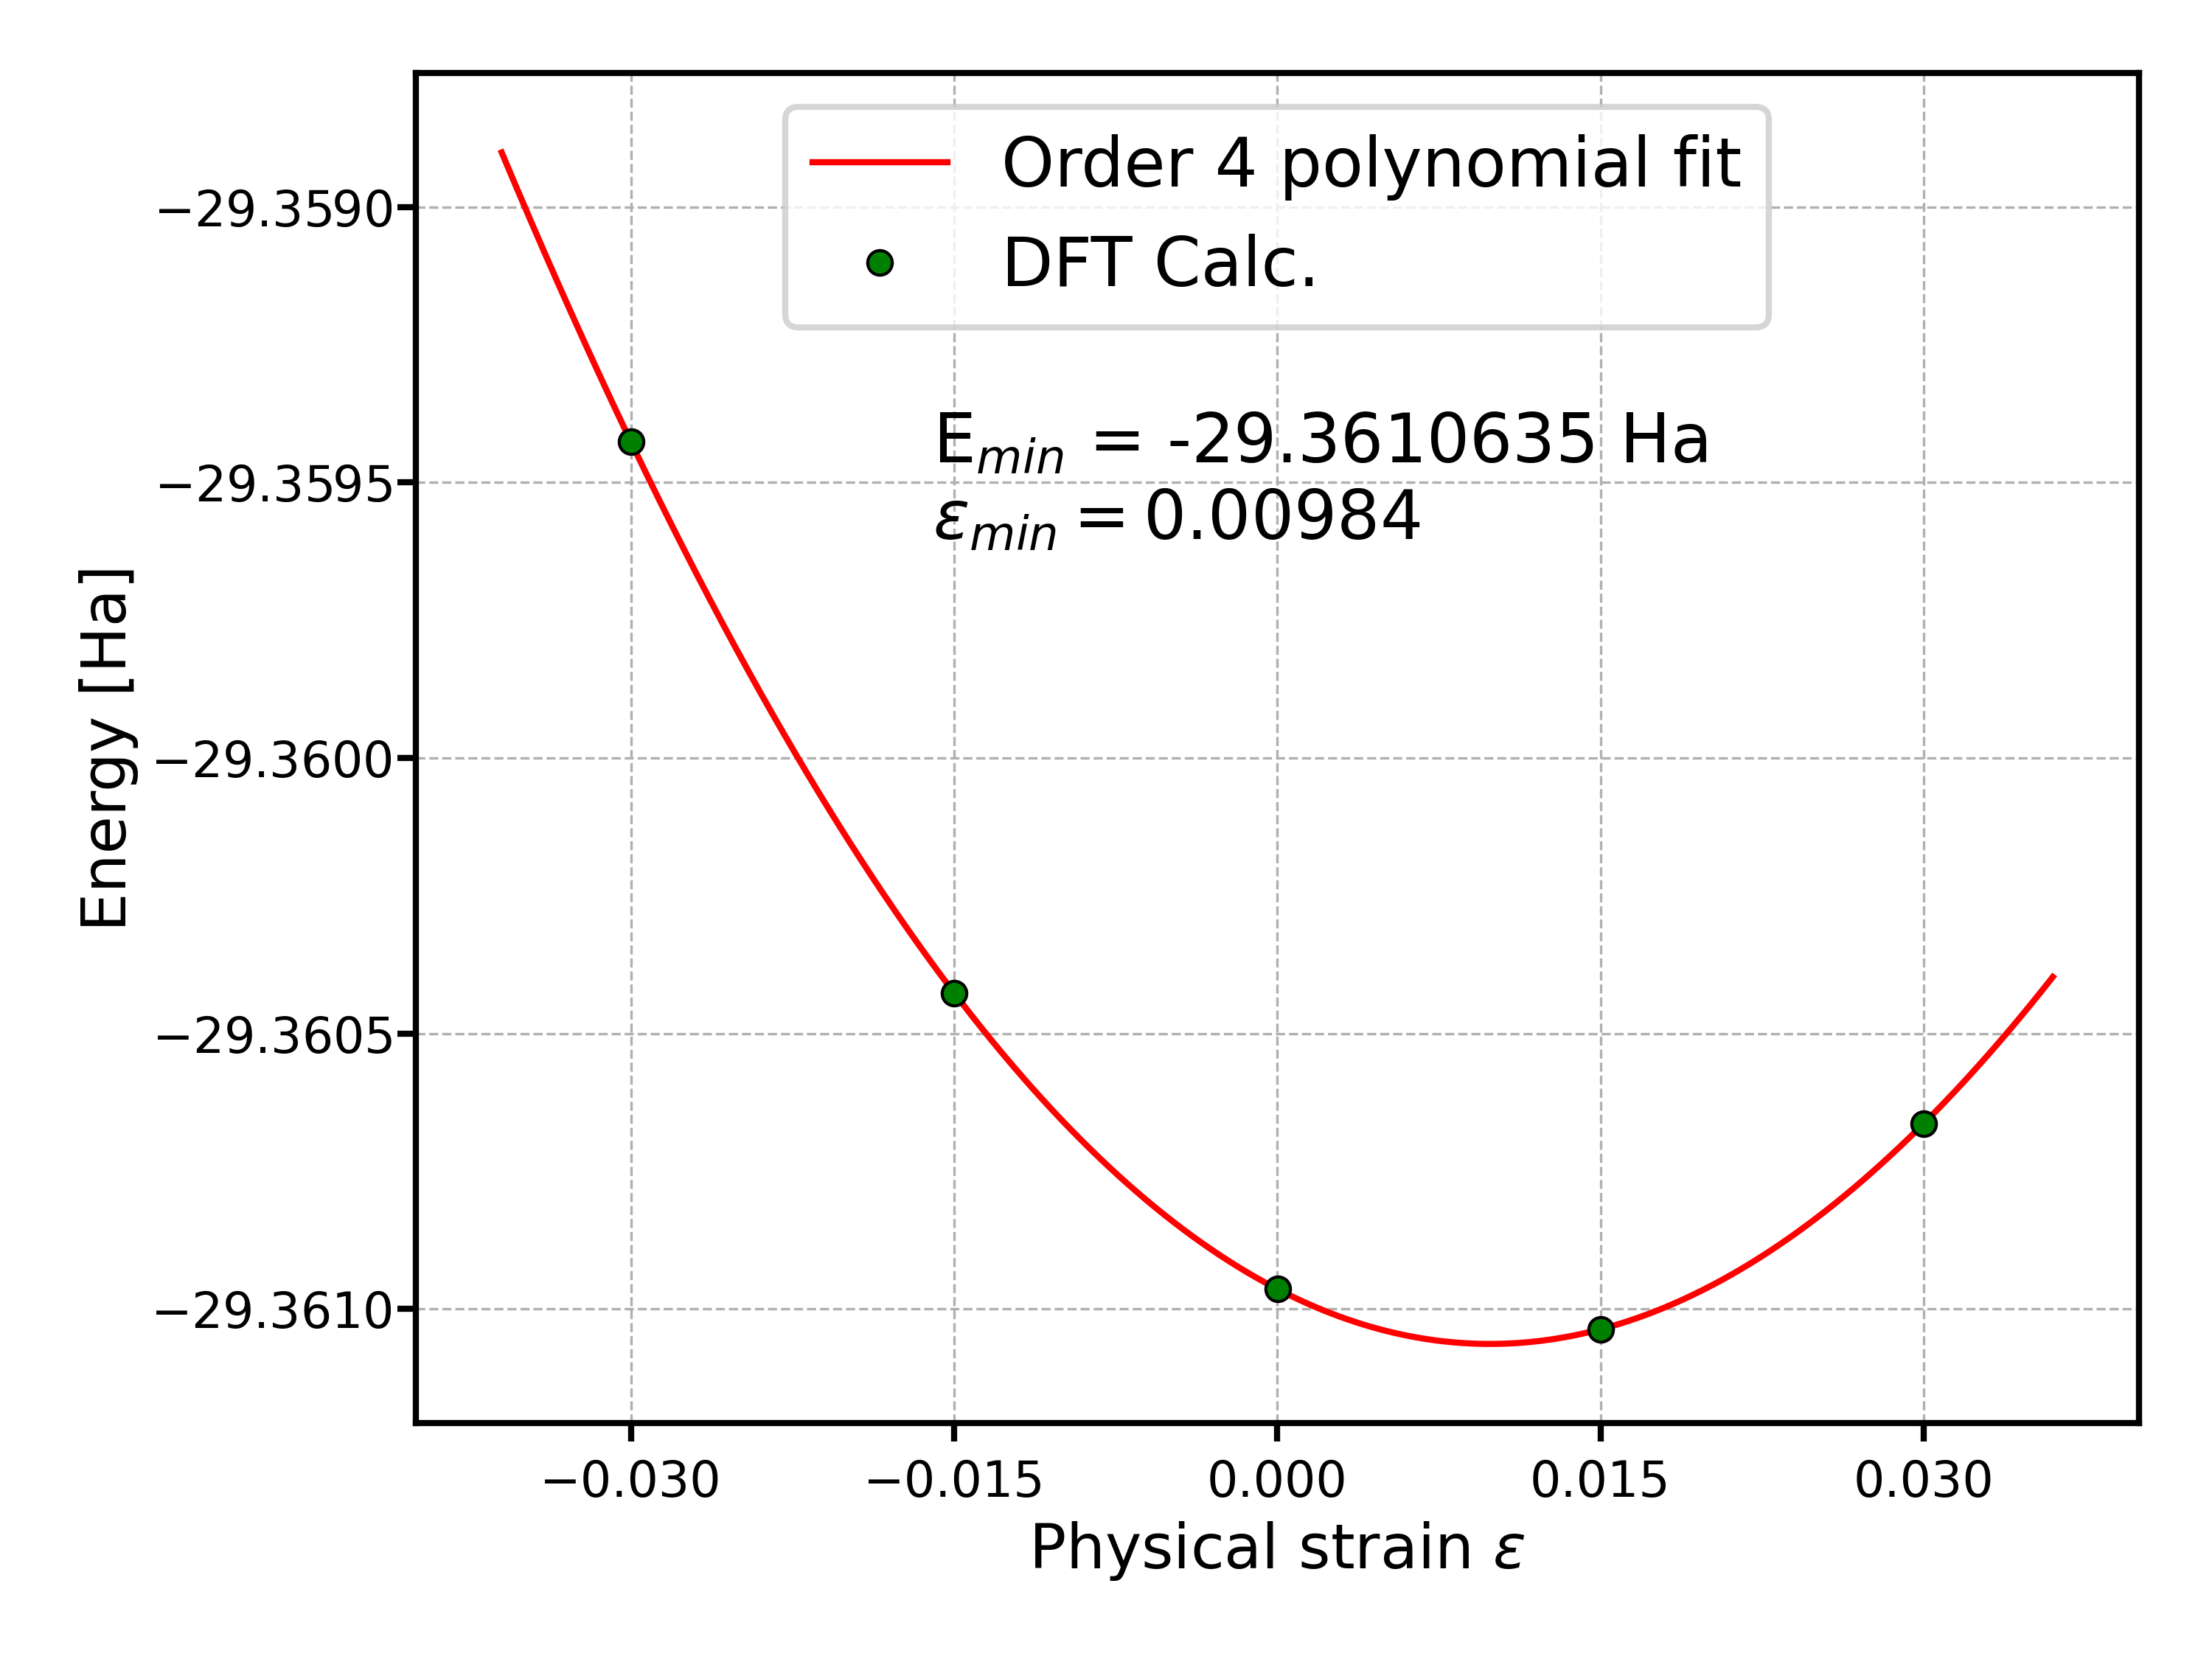
</figure>

At this point, you have completed the second optimization step (by varying only the $c/a$ ratio). The optimized structure is saved in the <b>coa-optimized.xml</b> file. The current values of the lattice parameter are obtained once more by running the script <code><b>lattice.parameters.py</b></code>

In [ ]:
%%bash -l
cd run_Be_OPT/COA
python3 -m excitingscripts.lattice.parameters -i coa-optimized.xml
cd ../../

As an output on the screen you should get


```

     Bravais lattice: Hexagonal
     a          b          c          alpha      beta       gamma
     4.32416    4.32416    6.58219   90.00000   90.00000  120.00000

```

Here, you can notice that by changing the $c/a$ ratio at fixed $V$, the values of $a$,$b$ and $c$ differ from the ones at the previous step. Now, you should move out to the parent directory, rename <b>COA</b> to <b>2-COA</b> (second optimization step, varying only $c/a$). Then, copy the <b>coa-optimized.xml</b> file to the current directory with the name <b>2-optimized.xml</b>.

In [ ]:
%%bash -l
cd run_Be_OPT
mv COA 2-COA
cp 2-COA/coa-optimized.xml 2-optimized.xml
cd ../

<a id='3-3'></a>
<hr style="border:1px solid #DDD"> </hr>

<b>STEP3: Optimizing again the volume</b>

<span style="color:firebrick;font-weight:bold">Notice</span>: Due to the fact that the volume and $c/a$ ratio have been already optimized once, we can increase the number of calculations at each step in order to achieve a better fitting accuracy.

Repeat now the procedure already explained in <b>STEP1</b>, running the script <code><b>optimize.setup.py</b></code> and using as entries values <span style="color:firebrick;font-weight:bold">2-optimized.xml</span>, <span style="color:firebrick;font-weight:bold">1</span>, <span style="color:firebrick;font-weight:bold">0.03</span>, and <span style="color:firebrick;font-weight:bold">11</span> in the given order. After having performed the calculation (running the script <code><b>optimize.submit.py</b></code> inside the directory <b>VOL</b>), you run <code><b>optimize.analyze.py</b></code> and get the following plot.

<figure>
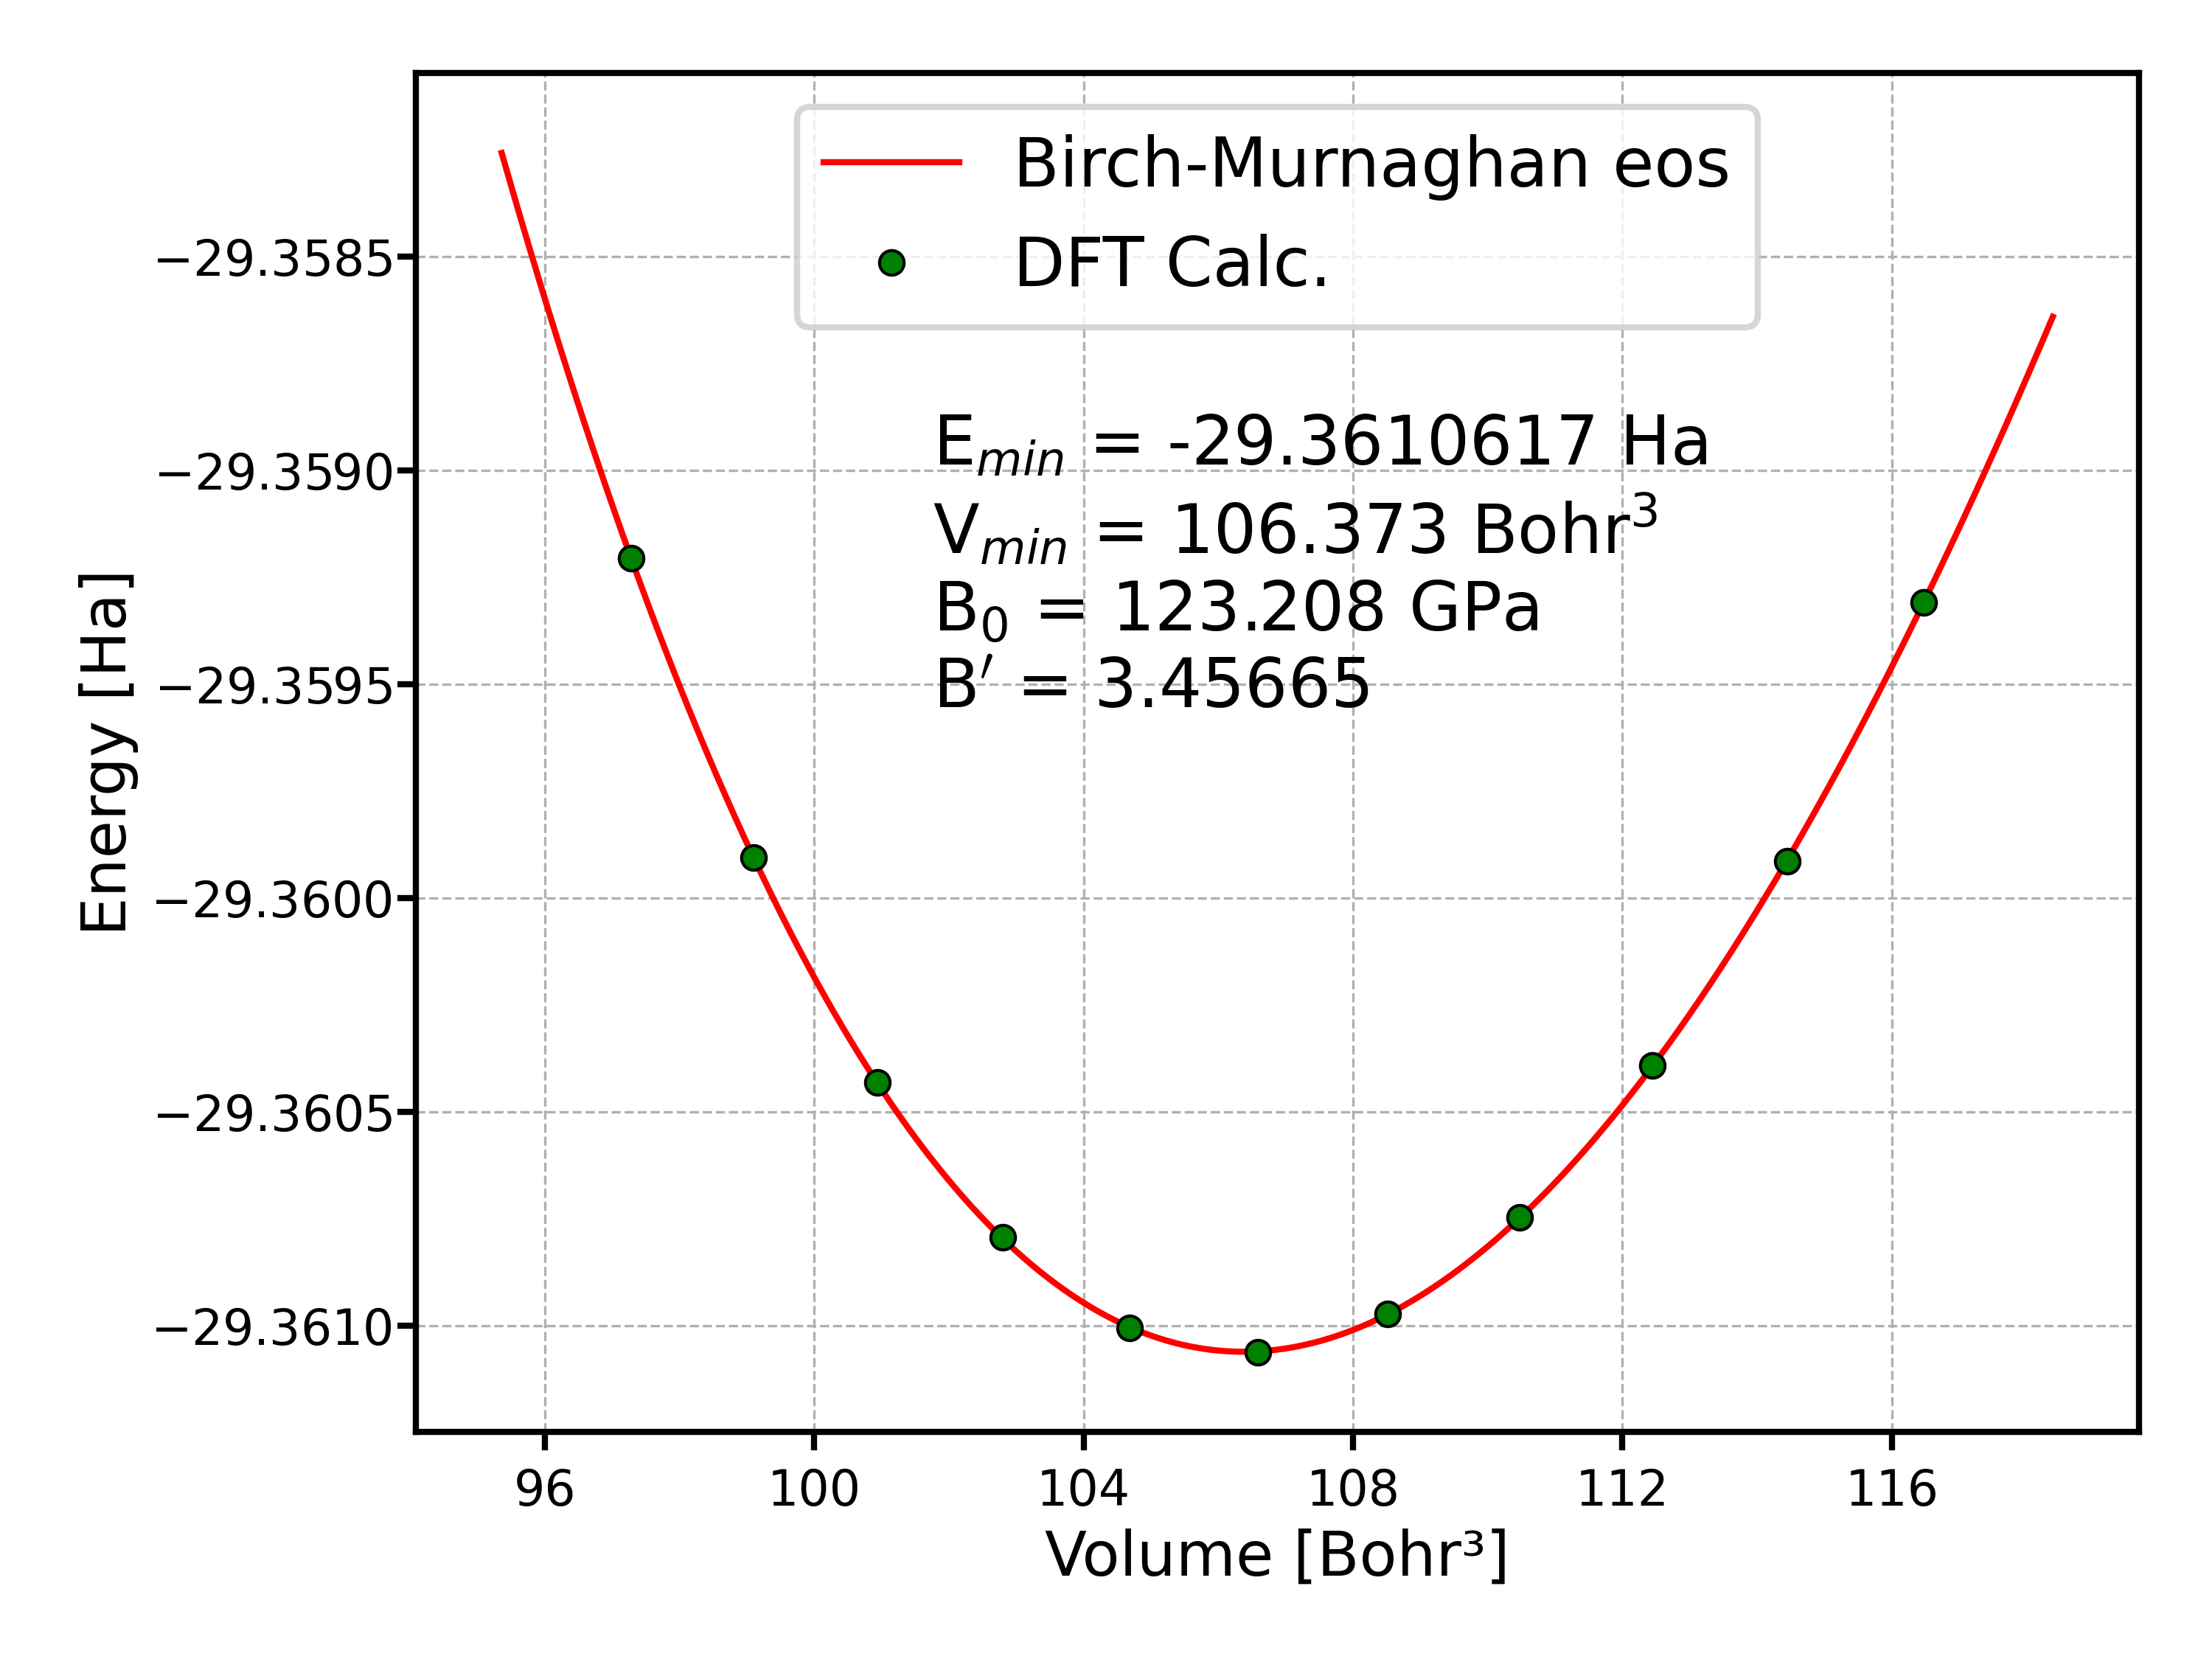
</figure>

At this point, you have optimized the volume for the second time. Follow the last part of <b>STEP1</b> and copy the file <b>vol-optimized.xml</b> to the parent directory under the name <b>3-optimized.xml<b>.

<a id='3-4'></a>
<hr style="border:1px solid #DDD"> </hr>

<b>STEP4: Optimizing again the</b> $c/a$ <b>ratio</b>

Proceed in a similar way to to <b>STEP2</b>. Run the script <code><b>optimize.lattice.py</b></code> using as entries values <span style="color:firebrick;font-weight:bold">3-optimized.xml</span>, <span style="color:firebrick;font-weight:bold">2</span>, <span style="color:firebrick;font-weight:bold">0.03</span>, and <span style="color:firebrick;font-weight:bold">11</span> in the given order. Using the same procedure as in the previous steps, you will end up with the following plot.

<figure>
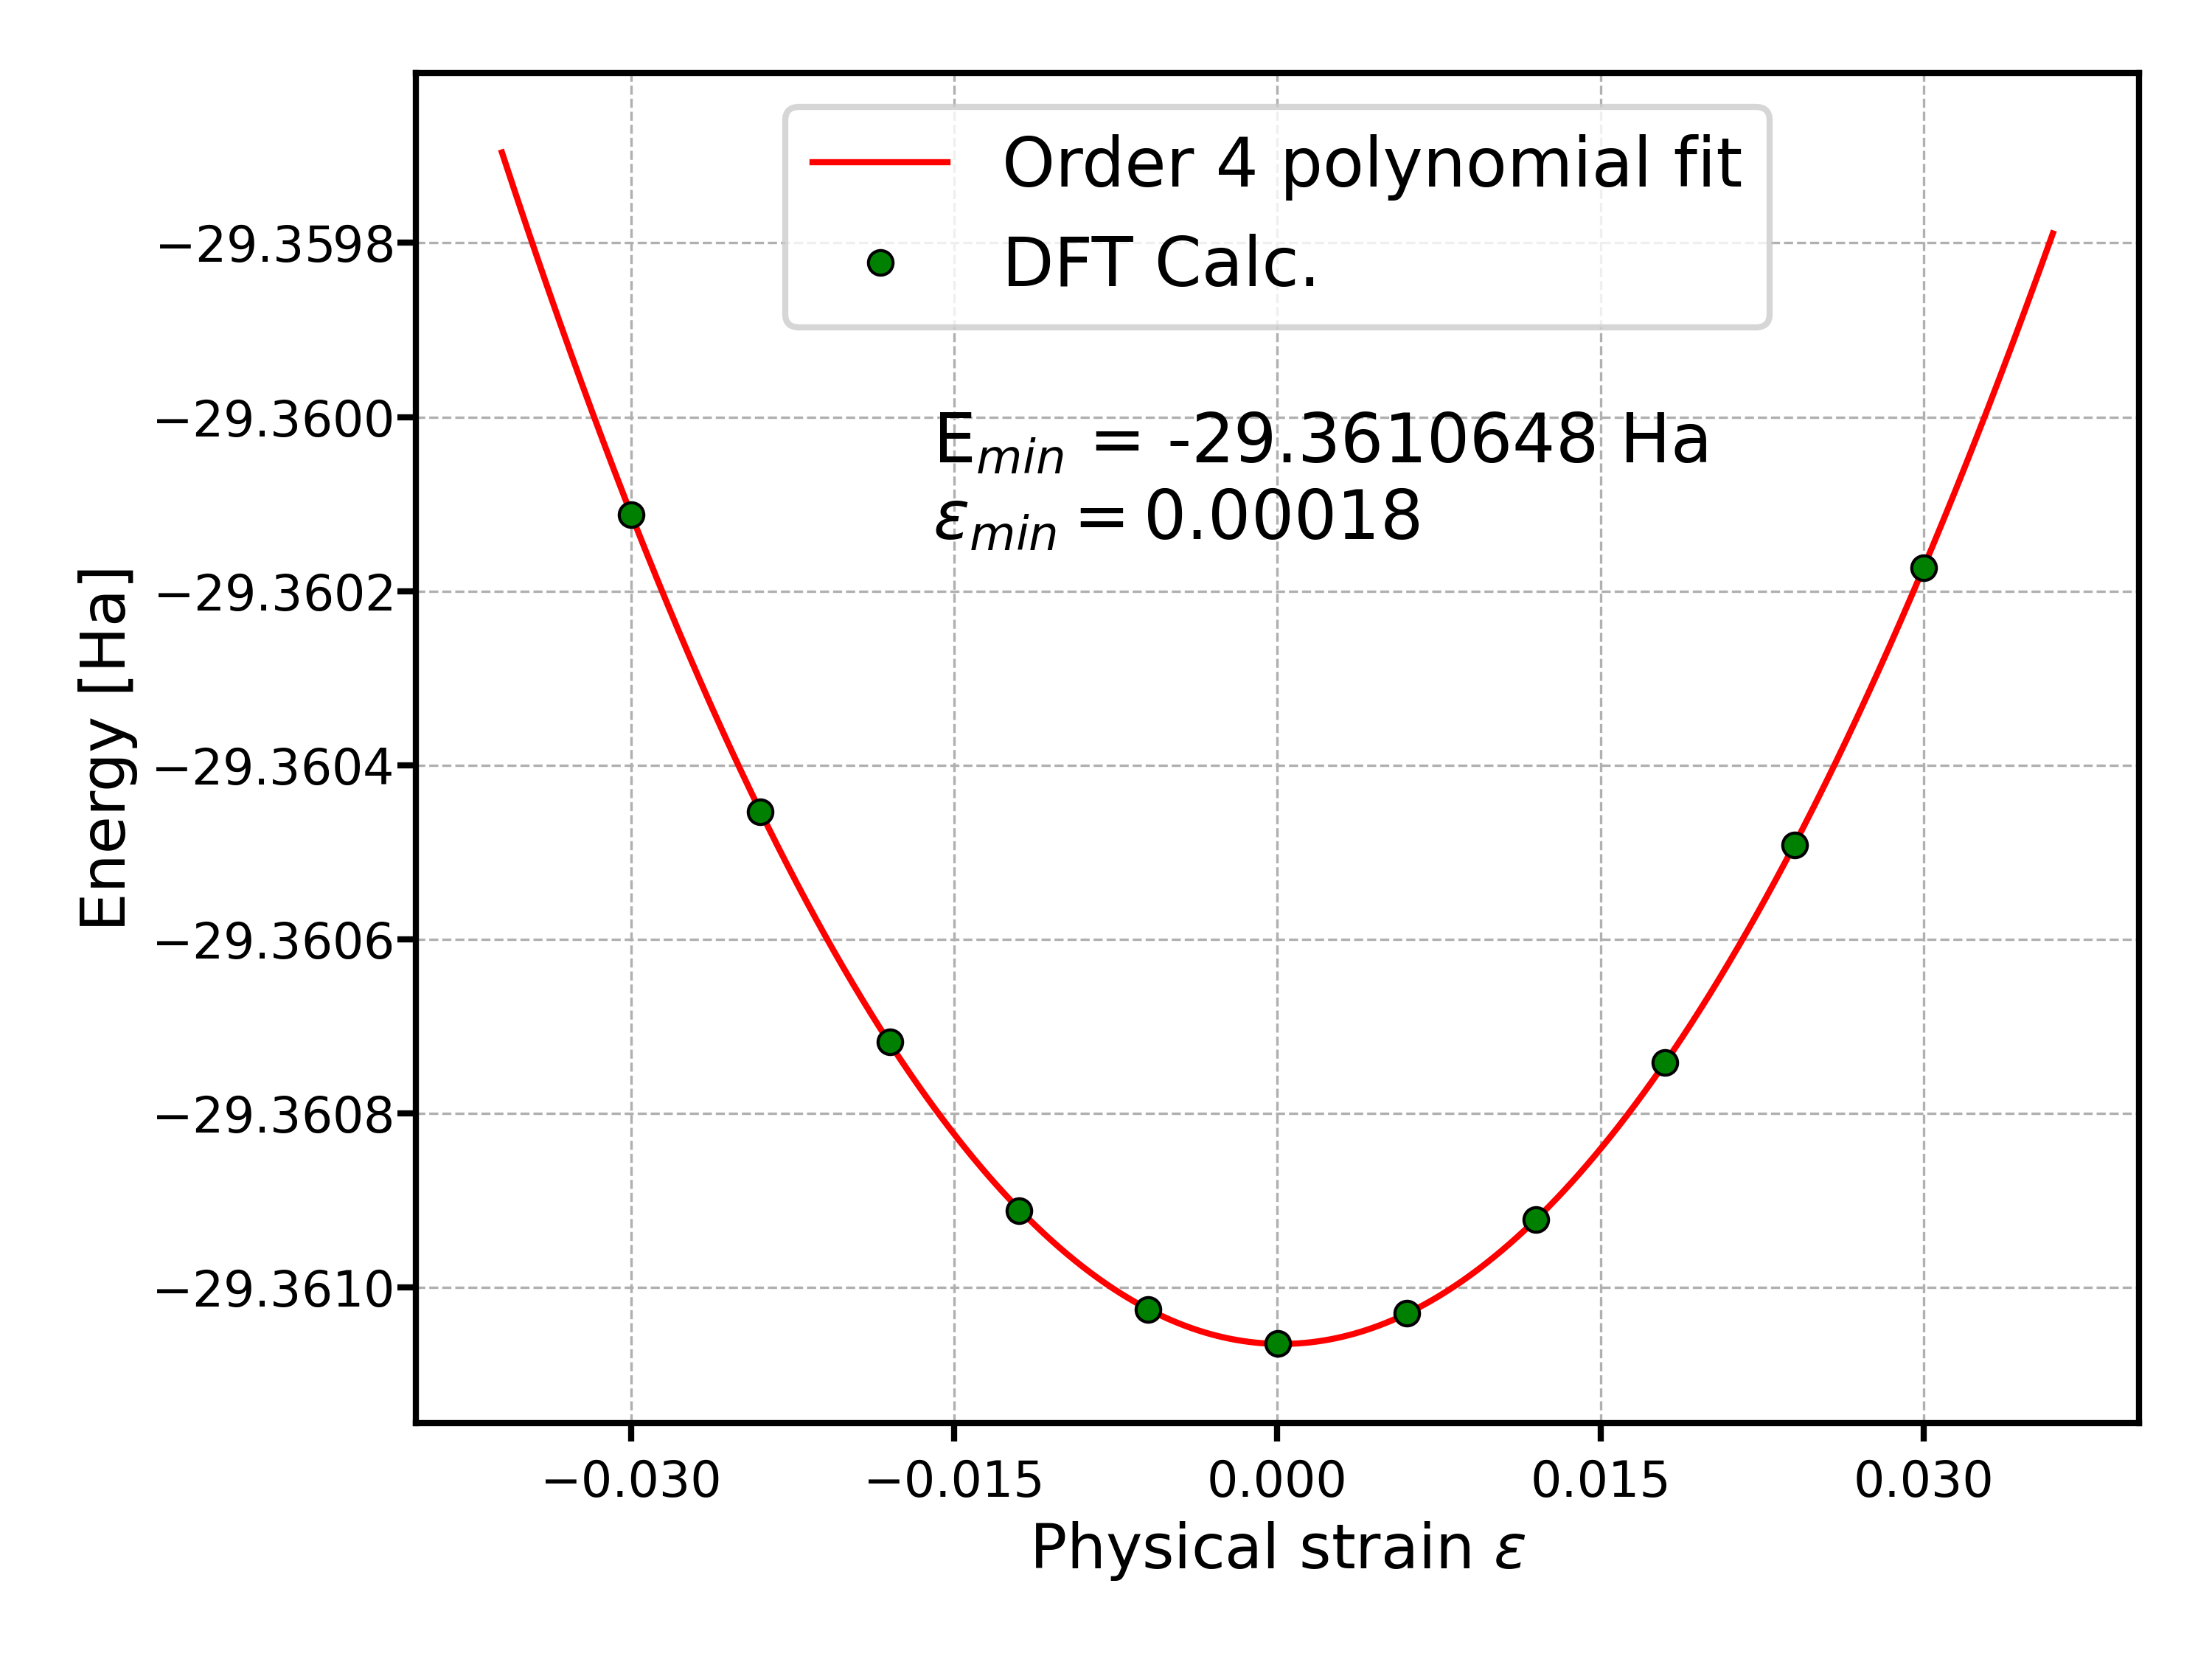
</figure>

At this point, the second optimization of the <i>c/a</i> ratio has been completed and the new optimized structure has been saved in <b>coa-optimized.xml</b>.

<a id='3-5'></a>
<hr style="border:1px solid #DDD"> </hr>

<b>Reaching convergence</b>

In the following table you find a summary of the results for the lattice parameters of the first 4 optimization steps.

| **Step** | **OPT** | **amin \[Bohr\]** | **bmin \[Bohr\]** | **cmin \[Bohr\]** | **αmin \[degrees\]** | **βmin \[degrees\]** | **γmin \[degrees\]** |
|----------|:--------|-------------------|-------------------|-------------------|----------------------|----------------------|----------------------|
| **0**        |         | 4.30000           | 4.30000           | 6.45000           | 90.00000             | 90.00000             | 120.00000            |
| **1**        | $V$     | 4.34538           | 4.34538           | 6.51806           | 90.00000             | 90.00000             | 120.00000            |
| **2**        | $c/a$   | 4.32416           | 4.32416           | 6.58219           | 90.00000             | 90.00000             | 120.00000            |
| **3**        | $V$     | 4.32127           | 4.32127           | 6.57779           | 90.00000             | 90.00000             | 120.00000            |
| **4**        | $c/a$   | 4.32088           | 4.32088           | 6.57897           | 90.00000             | 90.00000             | 120.00000            |



As you can see from the previous table, at the 4-th iteration you reached an overall convergence of the lattice parameters $a$, $b$, and $c$ of about <span style="color:firebrick;font-weight:bold">$\mathbf{1 \times 10^{-3}}$ Bohr</span>. If this result corresponds to the desired accuracy, you can stop the optimization procedure. Otherwise, you proceed with the next step and, using the new results, you check again the convergence behaviour of the equilibrium parameters.

In some case, it may happen that after some new optimization steps the values of the lattice parameters oscillate without reaching convergence. Then, you should improve the accuracy in the energy of the single calculations by correspondingly changing computational parameters such as <code><span style="color:mediumblue">ngridk</span></code>, <code><span style="color:mediumblue">rgkmax</span></code>, and <code><span style="color:mediumblue">epsengy</span></code>.

<a id='3-6'></a>
<hr style="border:1px solid #DDD"> </hr>

<b>Note on the accuracy of the calculations</b>

The quality of the results you can obtain for the structural optimization of a crystal using the procedure illustrated in this tutorial strongly depends on the accuracy in the determination of the energy of each single calculations. For instance, if one performs a minimization step of the $c/a$ ratio starting from the initial input file **Be_opt.xml**, and the parameters <code><span style="color:mediumblue">ngridk</span></code> and  <code><span style="color:mediumblue">rgkmax</span></code> are set as follows

```xml
   <groundstate 
      ...
      ngridk="3 3 2" 
      rgkmax="4.0" 
      ...>
   </groundstate>
```

a result is obtained which is similar to the one illustrated in the next plot, where no global minimum can be clearly identified.

<figure>
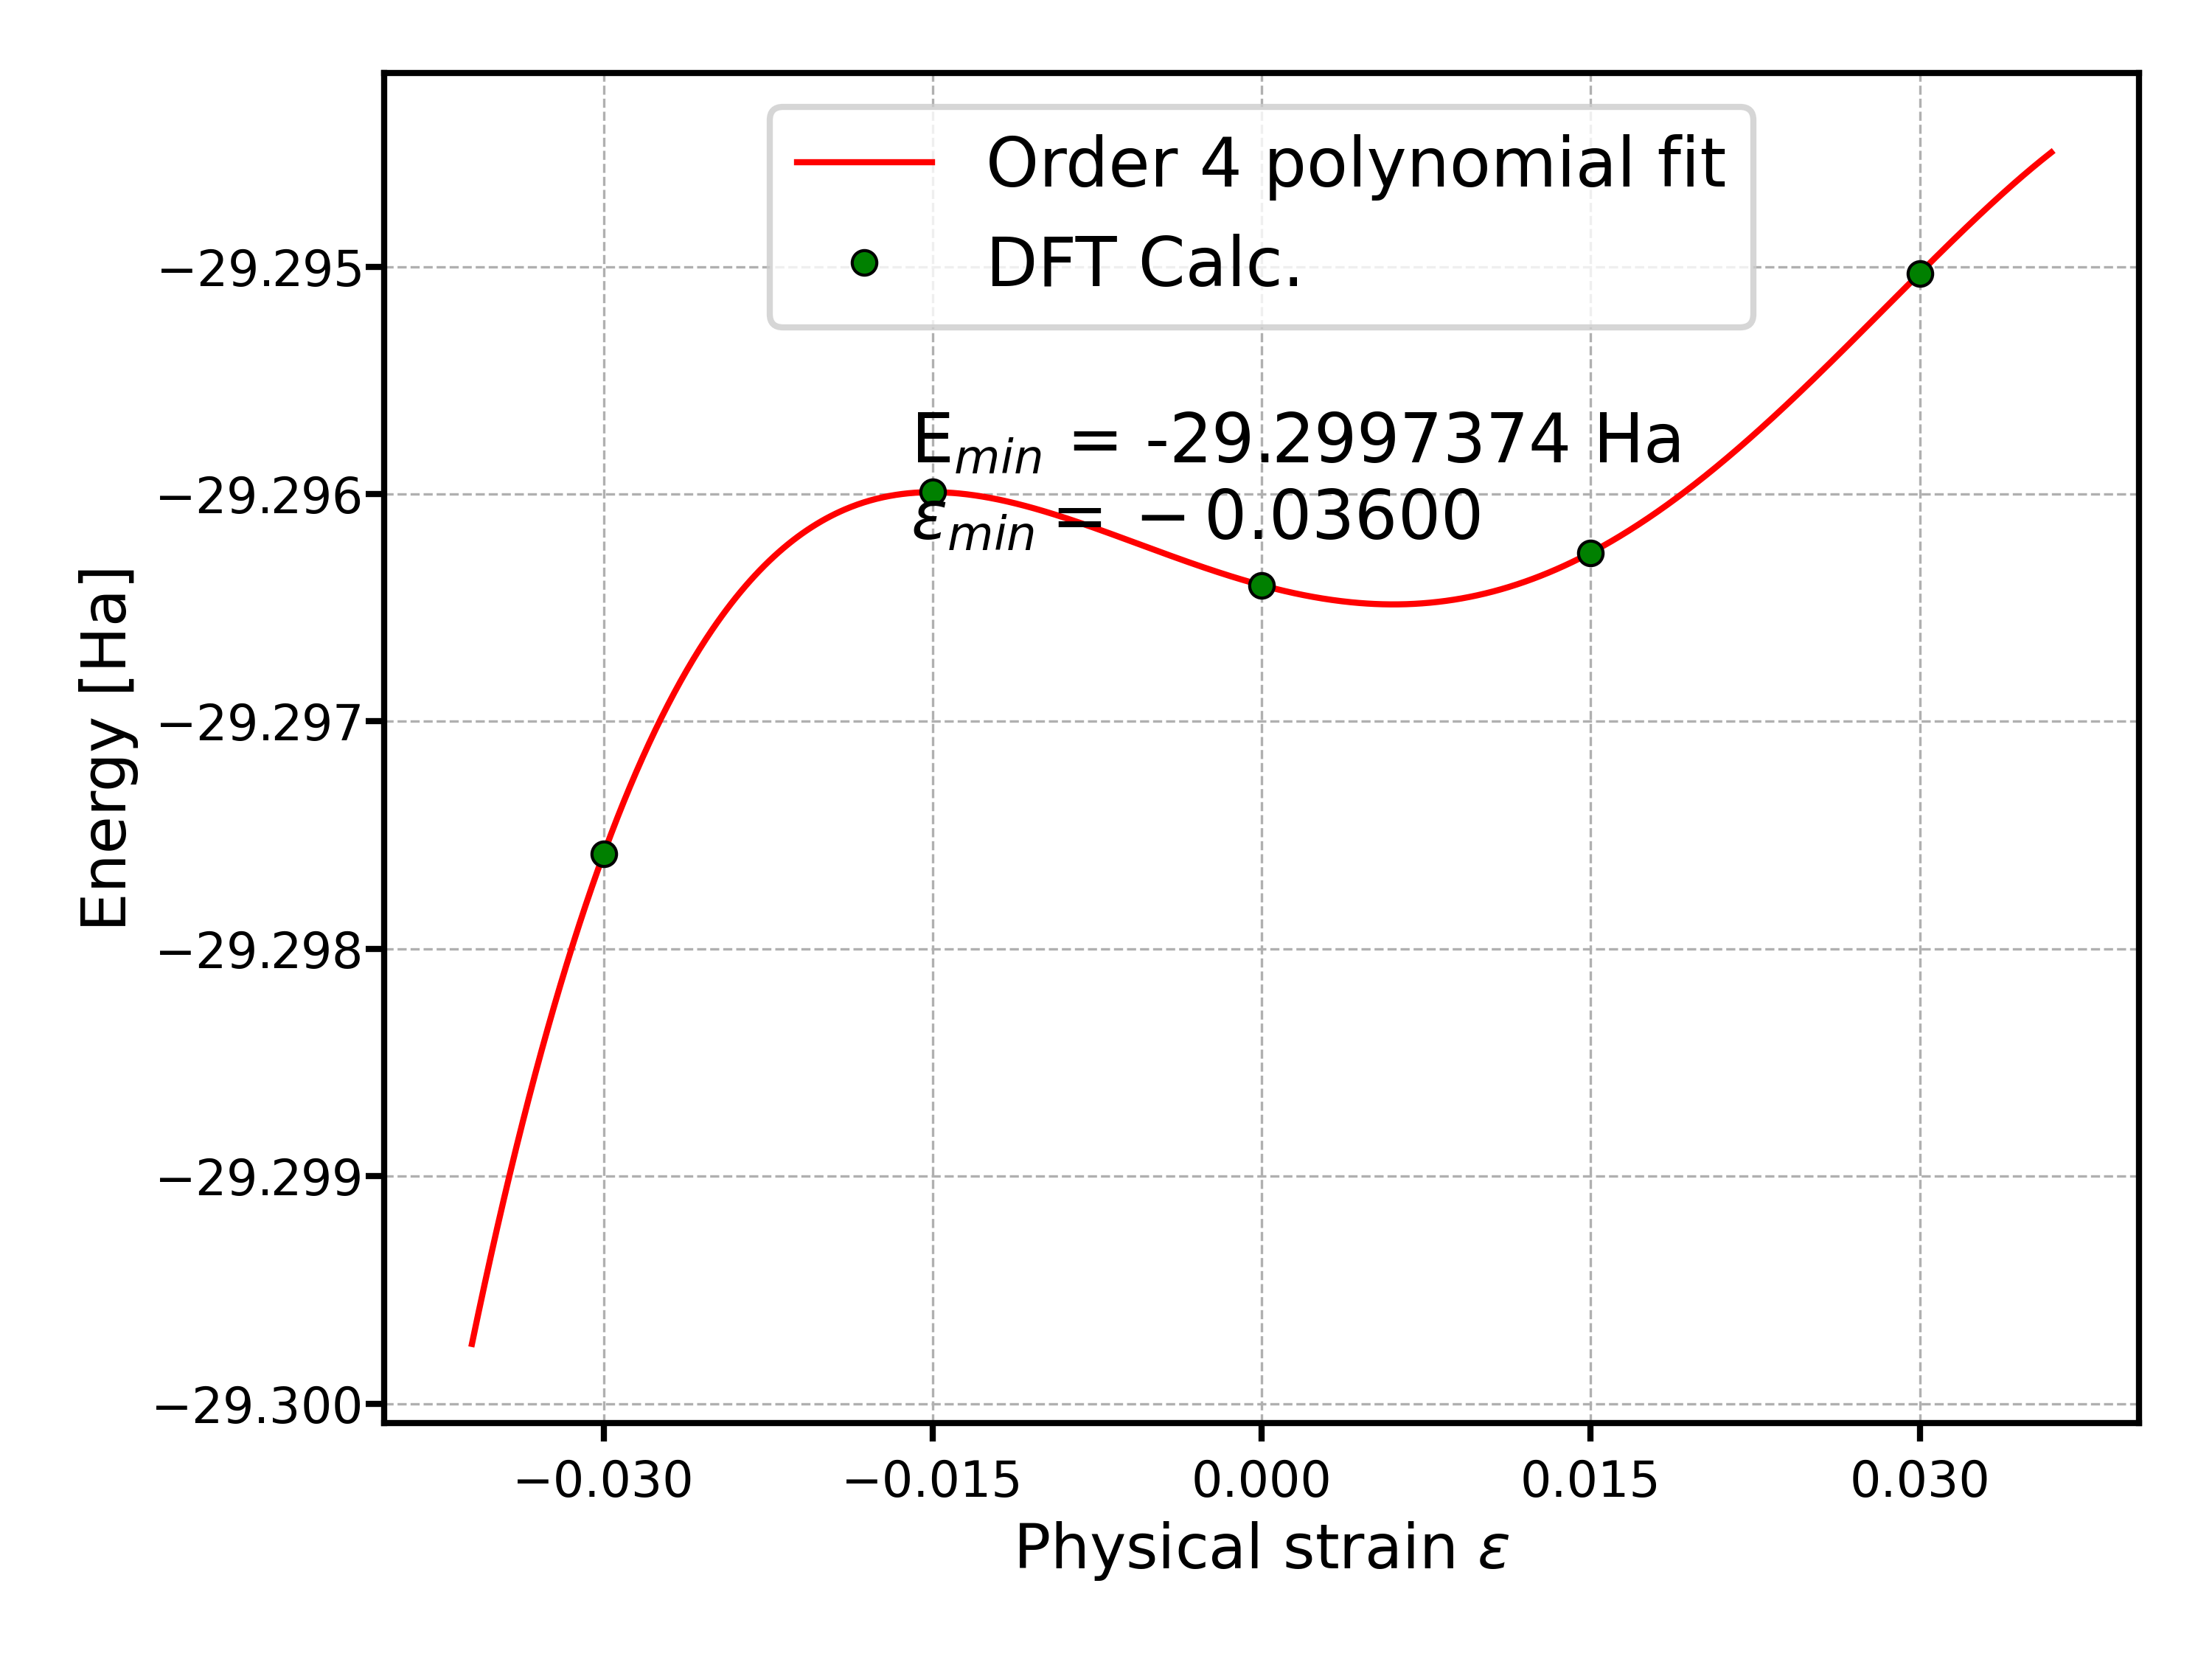
</figure>

In order to obtain reasonable results, a general rule is that the accuracy of the energy for each calculations should be <span style="color:green;font-weight:bold">much smaller </span>than the energy difference between two different calculations (two different points in the above plot).

<a id='3-7'></a>
<hr style="border:1px solid #DDD"> </hr>

<div style="border: 2px solid black; padding: 10px; margin: 10px;">
<span style="color:green"><b>Final step: Internal optimization</b></span>
    
The procedure shown in this tutorial optimizes the <span style="color:green"><b>cell parameters</b></span> of a crystal. If the crystal symmetry allows for <span style="color:green"><b>internal relaxation</b></span> of the atomic positions (*i.e.*, without changing the cell parameters) a single further calculation is necessary to optimize <span style="color:firebrick"><b>all degrees of freedom</b></span>  of the crystal. One has to

1. copy the <span style="color:firebrick"><b>last</b></span> optimized input <b>xml</b> file to <b>input.xml</b>;
2. be sure that the element <code><span style="color:green">relax</span></code> is present in <b>input.xml</b>;
3. perform a single calculation of <code><b>exciting</b></code>.
</div>

<hr style="border:2px solid #DDD"> </hr>